In [145]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import math
from matplotlib.scale import FuncScale

from pathlib import Path

from os.path import join
import os
from functools import partial
import pathlib
import shutil

import re


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.colors as mcolors


# load verification data

In [146]:
model_comparisons = [
    "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts_2025",
    
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/saved_verif",
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/saved_verif_confusion",
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/saved_verif_2025",
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/saved_verif_2025_v2",
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/verif_region_saved",
    
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/DOP/10m_big_dop/verif_region_saved",
    "/glade/derecho/scratch/dkimpara/goes_10km_train/DOP/10m_big_dop/forecasts_2025",
    
    "/glade/derecho/scratch/dkimpara/goes_10km_train/DOP/10m_big_train_anneal/forecasts_2025",
    
    "/glade/derecho/scratch/dkimpara/goes_10km_train/30m_omid/forecasts_2025",
    "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big/forecasts_2025",
    "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big3/forecasts_2022",
    "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_inv/forecasts_2022",
]

In [147]:
model_comparisons = {
    Path(d).parent.name: d for d in model_comparisons
}

baselines = {
    # "10m_big_2022":  "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts_workshop",
    # "30m_mpas":  "/glade/derecho/scratch/dkimpara/goes_10km_train/mpas/saved_verif_2025/",
    "30m_mpas":  "/glade/derecho/scratch/dkimpara/goes_10km_train/mpas/mpas_fixed/",
    "10m_climo": "/glade/derecho/scratch/dkimpara/goes_10km_train/baselines/climo_forecasts",
    "10m_persistence": "/glade/derecho/scratch/dkimpara/goes_10km_train/baselines/persistence_forecasts",
}

comparisons = baselines | model_comparisons

colors = {
    "10m_persistence": "0.5",
    "10m_climo": "0",
    "10m_big": "#D81B60", #magenta ish
    "10m_big_dop": "#FFC107",
    "10m_big_train_anneal": "#FFC107", #yellowish
    "20m_big": "#004D40", #greenish
    "20m_big3": "#FFC107", #blueish
    "20m_inv": "#1E88E5", 
    "30m_omid": "#1E88E5", #bluish
    "30m_mpas": "#1E88E5", #bluish
} #defaults to None in .get
linestyles = {
    "10m_persistence": "--",
    # "10m_climo": "--",
} #defaults to None in .get

model_labels = {
    "10m_persistence": "Persistence",
    "10m_big_dop": "DOP",
    "10m_big_train_anneal": "DOP",
    "10m_big": "10 minute DOP+",
    "20m_big": "20 minute",
    "20m_big3": "Big",
    "20m_inv": "Inverted",
    "30m_omid": "30 minute",
    "30m_mpas": "MPAS",
}

dfs = {k: pd.read_parquet(join(path, "verif.parquet")) for k, path in comparisons.items()}
# dfs = {k: df[df["forecast_step"] != 21.0] for k, df in dfs.items()}


dfs_init_time = {}
# add by init_hour
# for model in ["10m_big", "30m_mpas", "10m_persistence"]:
#     for t in [0,6,12,18]:
#         dfs_init_time[f"{model}_{t:02}z"] = pd.read_parquet(join(comparisons[model], f"verif_T{t:02}z.parquet"))

In [131]:
# dfs_all = {k: [pd.read_parquet(p) for p in Path(v).iterdir() if (p != "verif.parquet") and "parquet" in p.name] 
#            for k,v in comparisons.items()}

In [191]:
def plot_1d_metric(metric, channel, right_lim=None, top_lim=None):
    col_name = f"{metric}_C{channel:02}"
    
    fig, ax = plt.subplots(figsize=(5, 3))
    
    for model, df in dfs.items():
        timestep = int(model[:2]) / 60.
        ax.plot(df.forecast_step * timestep, df[col_name], label=model_labels.get(model, None), color=colors.get(model, None), linestyle=linestyles.get(model, None))
    
    ticks = [0.5] + [int(k) for k in range(1, math.ceil(max(df.forecast_step) * timestep + 1))]
    ax.set_xticks(ticks)
    
    ax.grid()
    ax.legend()

    ax.set_xlim(left=0.0,right=right_lim)
    if metric != "ME":
        ax.set_ylim(bottom=0.0, top=top_lim)
    else:
        ax.axhline(0.0, color="0")

    ax.set_xlabel('Forecast hour')
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} C{channel:02}")
    plt.show()

def plot_1d_metric_models(dfs, metric, channel, right_lim=None, top_lim=None, colors=colors):
    col_name = f"{metric}_C{channel:02}"
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    for model, df in dfs.items():
        timestep = int(model[:2]) / 60.
        ax.plot(df.forecast_step * timestep, df[col_name], label=model_labels.get(model, None), color=colors.get(model, None), linestyle=linestyles.get(model, None))
    
    ticks = [0.5] + [int(k) for k in range(1, math.ceil(max(df.forecast_step) * timestep + 1))]
    ax.set_xticks(ticks)
    
    ax.grid()
    ax.legend(loc="upper right")

    ax.set_xlim(left=0.0,right=right_lim)
    if "ME" not in metric:
        ax.set_ylim(bottom=0.0, top=top_lim)
    else:
        ax.axhline(0.0, color="0")

    ax.set_xlabel('Forecast hour')
    ax.set_ylabel(metric)

def plot_1d_envelope(metric, channel, models=[], right_lim=None, top_lim=None, bot_lim=None):
    col_name = f"{metric}_C{channel:02}"
    
    fig, ax = plt.subplots(figsize=(8, 6))
    if not models:
        models = dfs.keys()
    for model in models:
        df = dfs[model]
        timestep = int(model[:2]) / 60.
        p = ax.plot(df.forecast_step * timestep, df[col_name],label=model_labels.get(model, None), color=colors.get(model, None), linestyle=linestyles.get(model, None))
        color = p[0].get_color()
        if "climo" not in model and "persistence" not in model:
            all_dfs = dfs_all[model]
            for df in all_dfs:
                ax.plot(df.forecast_step * timestep, df[col_name], color=color, alpha=0.05)
        
    ticks = [0.5] + [int(k) for k in range(1, math.ceil(max(df.forecast_step) * timestep + 1))]
    ax.set_xticks(ticks)
    
    ax.grid()
    # ax.legend()

    ax.set_xlim(left=0.0,right=right_lim)
    ax.set_ylim(bottom=bot_lim, top=top_lim)
    if metric == "ME":
        ax.axhline(0.0, color="0")

    ax.set_xlabel('Forecast hour')
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} C{channel:02}")
    plt.show()

def plot_1d_by_channel(metric, model, right_lim=None, top_lim=None):
    
    fig, ax = plt.subplots(figsize=(8,5))
    df = dfs[model]
    cols = [c for c in df.columns if metric in c]
    timestep = int(model[:2]) / 60.
    print(cols)
    for col in cols:
        channel = col[-3:]
        ax.plot(df.forecast_step * timestep, df[col], label=channel)
    
    ticks = [0.5] + [int(k) for k in range(1, math.ceil(max(df.forecast_step) * timestep + 1))]
    ax.set_xticks(ticks)
    
    ax.grid()
    # ax.legend()

    ax.set_xlim(left=0.0,right=right_lim)
    if metric != "ME":
        ax.set_ylim(bottom=0.0, top=top_lim)
    else:
        ax.axhline(0.0, color="0")

    ax.set_xlabel('Forecast hour')
    ax.set_ylabel(metric)
    plt.legend()

['MAESS_region_right_C04', 'MAESS_region_right_C07', 'MAESS_region_right_C08', 'MAESS_region_right_C09', 'MAESS_region_right_C10', 'MAESS_region_right_C13']
['MAESS_C04', 'MAESS_C07', 'MAESS_C08', 'MAESS_C09', 'MAESS_C10', 'MAESS_C13']


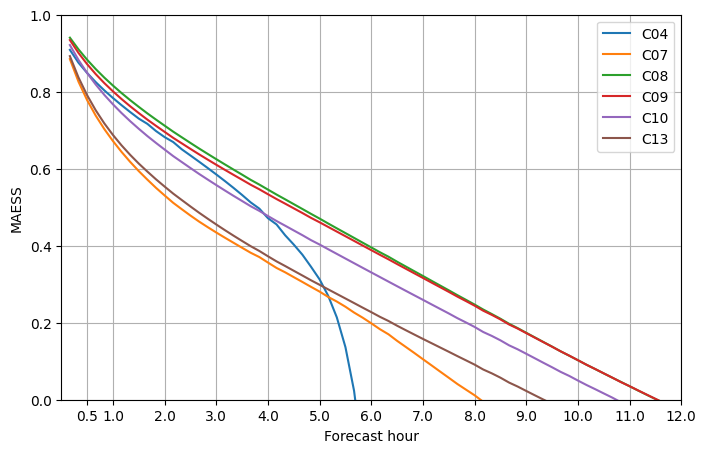

<Figure size 640x480 with 0 Axes>

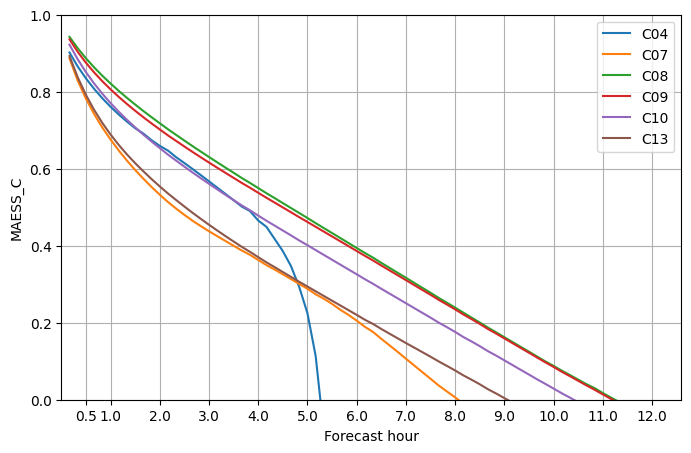

In [193]:
plot_1d_by_channel("MAESS_region_right", "10m_big", right_lim=12, top_lim=1)
plt.ylabel("MAESS")
plt.savefig("figures/maess_channel.png", dpi=300)
plt.figure()
plot_1d_by_channel("MAESS_C", "10m_big", top_lim=1)


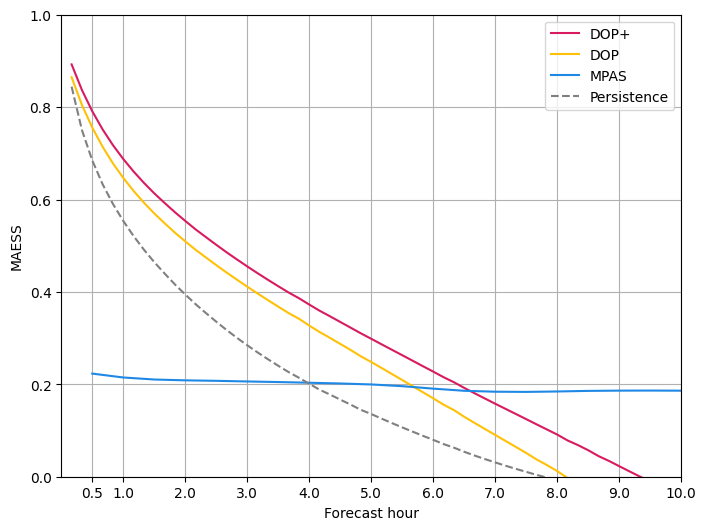

In [194]:
models = ["10m_big", "10m_big_dop",
          "30m_mpas", "10m_persistence",
          ]
dfs_ts_compare = {m: dfs[m] for m in models}
plot_1d_metric_models(dfs_ts_compare, "MAESS_region_right", 13, right_lim=10, top_lim=1)
plt.ylabel("MAESS")
plt.savefig("figures/maess_models.png", dpi=300)

In [195]:
models = ["10m_big", "10m_big_dop",
          "30m_mpas", "10m_persistence",
          ]
dfs_ts_compare = {m: dfs[m] for m in models}

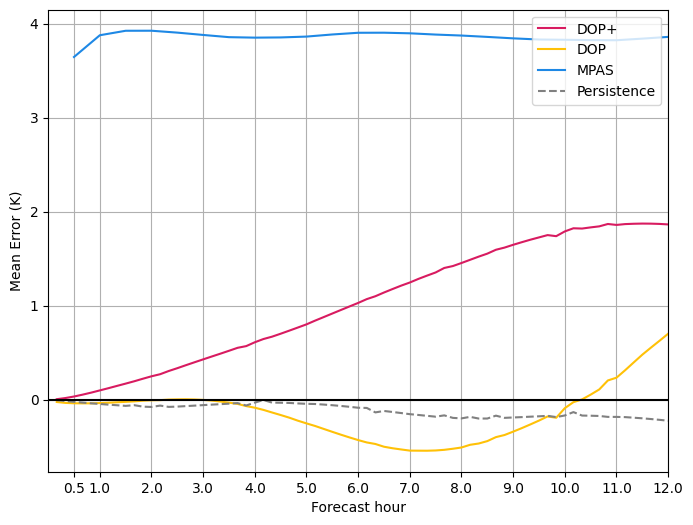

In [196]:
# plot_1d_metric("MAE", 13)
# plot_1d_metric("RMSE", 13,  top_lim = 20)
# plot_1d_metric("ME", 13)
# plot_1d_metric_models(dfs_ts_compare, "ME", 13, right_lim=None, top_lim=None)
plot_1d_metric_models(dfs_ts_compare, "ME_region_right", 13, right_lim=12, top_lim=None)
plt.ylabel("Mean Error (K)")
plt.savefig("figures/ME.png", dpi=300)

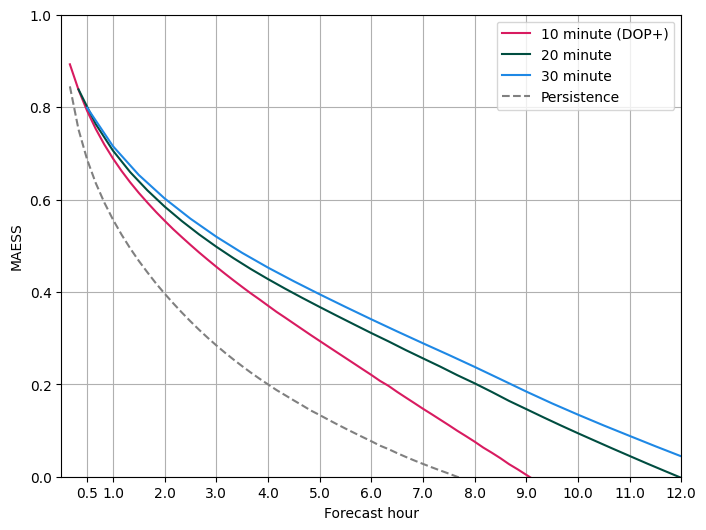

In [201]:
models = ["10m_big", "20m_big", "30m_omid", "10m_persistence"]
model_labels["10m_big"] = "10 minute (DOP+)"
model_labels["20m_big"] = "20 minute"

dfs_ts_compare = {m: dfs[m] for m in models}
plot_1d_metric_models(dfs_ts_compare, "MAESS", 13, right_lim=12, top_lim=1)
plt.savefig("figures/maess_timestep.png", dpi=300)

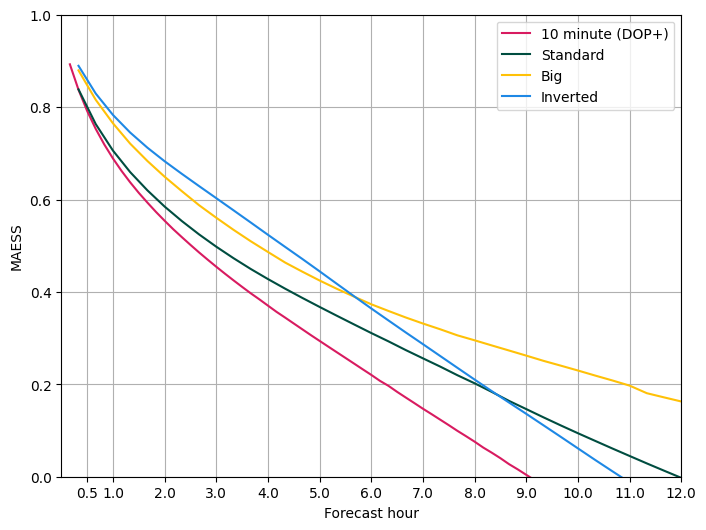

In [202]:
models = ["10m_big", "20m_big", "20m_big3", "20m_inv"]
dfs_ts_compare = {m: dfs[m] for m in models}

model_labels["20m_big"] = "Standard"

plot_1d_metric_models(dfs_ts_compare, "MAESS", 13, right_lim=12, top_lim=1)
plt.savefig("figures/maess_model_size.png", dpi=300)

# FFT

In [203]:
def compute_mean_fft(true_fft):
    """
    true_fft: iterable of 1d arrays
    """
    total = 0.0
    num_rows = 0
    for row in true_fft:
        if not any(np.isnan(row)):
            total += row
            num_rows += 1
    return total / num_rows

def compute_wavelengths(wavenumbers, dx):
    min_c = len(wavenumbers)
    wavelengths = 1 / np.fft.rfftfreq(min_c * 2, d=dx)[:-1]
    return wavelengths
    

def plot_fft_channel(model, channel, forecast_hours, color="teal", ylims=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    true_ffts = dfs[model][f"FFT_true_C{channel:02}"]
    true_fft = compute_mean_fft(true_ffts)
    
    xlabel = compute_wavelengths(true_fft, 10)

    ax.loglog(xlabel, true_fft, label="Obs", color="0")

    df = dfs[model]
    timestep = int(model[:2]) / 60.

    forecast_steps = (np.array(forecast_hours) / timestep).astype(int)
    forecast_steps = [1,2] + list(forecast_steps)

    col_name = f"FFT_C{channel:02}"

    #### plot model mean ####
    mean_fft = compute_mean_fft(df[col_name])
    ax.loglog(xlabel, mean_fft, label="Model mean", color="0", linestyle="dashed")

    #### plot forecast steps #####
    df = df[df["forecast_step"].isin(forecast_steps)]
    i = 0
    for _,row in df.iterrows():
        spectrum = row[col_name]
        ax.loglog(xlabel, spectrum, 
                  label=f"{row["forecast_step"] * timestep:.02f}h",
                  color=color,
                  alpha=(len(df) - i) / len(df),)
        i += 1

    if ylims:
        ax.set_ylim(*ylims)
    ax.set_xlim(ax.get_xlim()[::-1])


    ax.set_title(f"{model} model; Power Spectrum C{channel:02}")
    ax.legend()
    plt.show()

def plot_fft_fc_channel(model, channel, forecast_hours, color="teal", ylims=[-2, 2], base=np.e):
    fig, ax = plt.subplots(figsize=(10, 6))
    true_ffts = dfs[model]
    
    df = dfs[model]
    timestep = int(model[:2]) / 60.
    forecast_steps = (np.array(forecast_hours) / timestep).astype(int)
    forecast_steps = [1,2] + list(forecast_steps)

    #### plot forecast steps #####
    #### fractional change against obs #####
    for i, fs in enumerate(forecast_steps):
        true_fft = true_ffts[true_ffts["forecast_step"] == fs][f"FFT_true_C{channel:02}"]
        pred_fft = df[df["forecast_step"] == fs][f"FFT_C{channel:02}"]
        frac_change = (pred_fft / true_fft).values[0]
        
        xlabel = compute_wavelengths(frac_change, 10)

        ax.plot(xlabel, frac_change,
                  label=f"{fs * timestep:.02f}h",
                  color=color,
                  alpha=(len(forecast_steps) - i) / len(forecast_steps),)
    ax.set_xscale("log", base=10)
    ax.set_yscale("log", base=np.e)
    ax.set_xlim(ax.get_xlim()[::-1])


    ax.axhline(1.0, color="0")
    
    exponents = np.arange(ylims[0], ylims[1] + 1)
    yticks = np.e ** exponents
    ax.set_yticks(yticks)
    ax.set_yticklabels(exponents)

    if ylims:
        ax.set_ylim(np.e ** ylims[0], np.e ** ylims[1])

    ax.set_xlabel("Wavelength (km)")
    ax.set_ylabel("ln Fractional Change")
    ax.set_title(f"{model} model; Fractional Change C{channel:02}")
    ax.legend()
    plt.show()




In [206]:
def plot_fft_fc_compare_channel(models, channel, forecast_hours, linestyles, ylims=[-2, 2], xlims=[], base=np.e, colors=colors):
    fig, ax = plt.subplots(figsize=(4, 4))
    for model in models:
        true_ffts = dfs[model]
        
        df = dfs[model]
        timestep = int(model[:2]) / 60.
        for fh,lstyle in zip(forecast_hours, linestyles):
            fs = int(fh/timestep)

            # forecast_steps = [1,2] + list(forecast_steps)

            #### plot forecast steps #####
            #### fractional change against obs #####
            true_fft = true_ffts[true_ffts["forecast_step"] == fs][f"FFT_true_C{channel:02}"]
            pred_fft = df[df["forecast_step"] == fs][f"FFT_C{channel:02}"]
            frac_change = (pred_fft / true_fft).values[0]
            
            xlabel = compute_wavelengths(frac_change, 10)
            ax.plot(xlabel, frac_change,
                    label=model_labels.get(model, None) if lstyle=="-" else None,
                    color=colors.get(model, None),
                    linestyle=lstyle,
                    alpha= 0.8 if fh > 1 else 1)
            
    ax.set_xscale("log", base=10)
    ax.set_yscale("log", base=np.e)
    ax.set_xlim(ax.get_xlim()[::-1])
    # ax.set_xticks(np.arange(1.,5.) ** 10.)
    # ax.set_xticklabels(np.arange(1,5) ** 10)

    ax.axhline(1.0, color="0")
    
    exponents = np.arange(ylims[0], ylims[1] + 1)
    yticks = np.e ** exponents
    ax.set_yticks(yticks)
    ax.set_yticklabels(exponents)

    if ylims:
        ax.set_ylim(np.e ** ylims[0], np.e ** ylims[1])
    if xlims:
        ax.set_xlim(10 ** xlims[0], 10 ** xlims[1])

    ax.set_xlabel("Wavelength (km)")
    ax.set_ylabel("Log fractional Change")
    ax.legend()


/glade/derecho/scratch/dkimpara/tmp/ipykernel_28122/1036120911.py:15: RuntimeWarning: divide by zero encountered in divide
  wavelengths = 1 / np.fft.rfftfreq(min_c * 2, d=dx)[:-1]


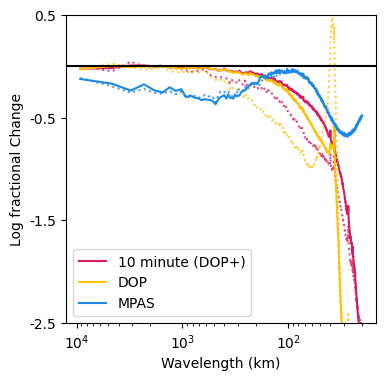

In [207]:
forecast_hours = [1, 3]

models = ["10m_big", "10m_big_dop", "30m_mpas"]

plot_fft_fc_compare_channel(models, 13, forecast_hours, ["-", ":"], ylims=[-2.5, 0.5])
plt.savefig("figures/ln_frac_change.png", dpi=300)


/glade/derecho/scratch/dkimpara/tmp/ipykernel_28122/1036120911.py:15: RuntimeWarning: divide by zero encountered in divide
  wavelengths = 1 / np.fft.rfftfreq(min_c * 2, d=dx)[:-1]


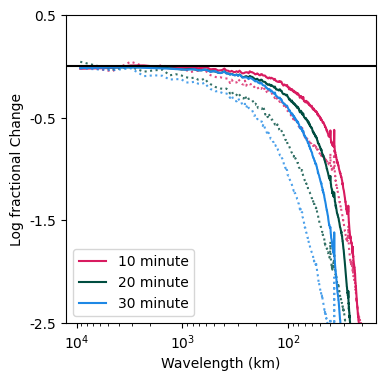

In [210]:
models = ["10m_big", "20m_big", "30m_omid"]
model_labels["10m_big"] = "10 minute"
model_labels["20m_big"] = "20 minute"

plot_fft_fc_compare_channel(models, 13, forecast_hours, ["-", ":"], ylims=[-2.5, 0.5])
plt.savefig("figures/ln_frac_change_timestep.png", dpi=300)

/glade/derecho/scratch/dkimpara/tmp/ipykernel_28122/1036120911.py:15: RuntimeWarning: divide by zero encountered in divide
  wavelengths = 1 / np.fft.rfftfreq(min_c * 2, d=dx)[:-1]


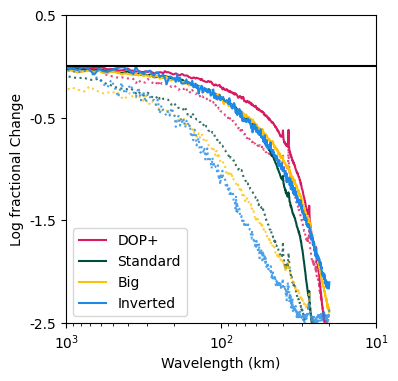

In [211]:
models = ["10m_big", "20m_big", "20m_big3", "20m_inv"]

model_labels["10m_big"] = "DOP+"
model_labels["20m_big"] = "Standard"

plot_fft_fc_compare_channel(models, 13, forecast_hours, ["-", ":"], ylims=[-2.5, 0.5], xlims=[3,1])
plt.savefig("figures/ln_frac_change_model_size.png", dpi=300)

/glade/derecho/scratch/dkimpara/tmp/ipykernel_28122/1036120911.py:15: RuntimeWarning: divide by zero encountered in divide
  wavelengths = 1 / np.fft.rfftfreq(min_c * 2, d=dx)[:-1]


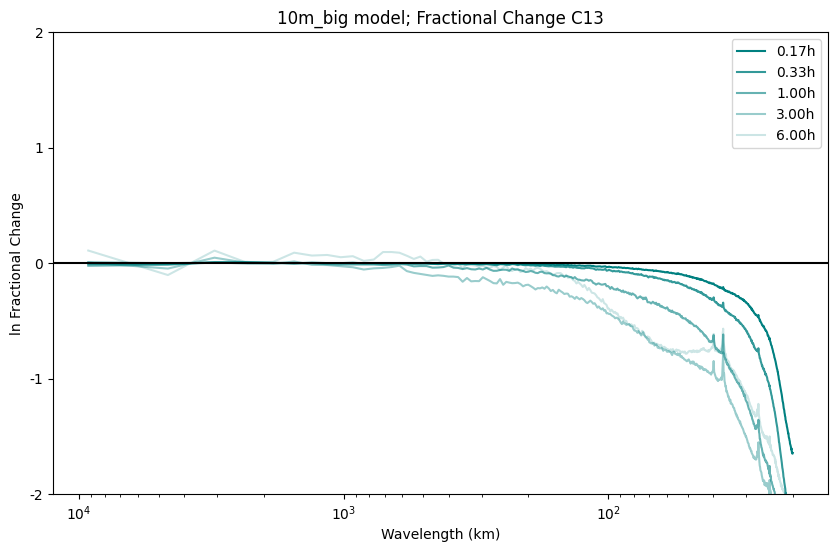

/glade/derecho/scratch/dkimpara/tmp/ipykernel_28122/1036120911.py:15: RuntimeWarning: divide by zero encountered in divide
  wavelengths = 1 / np.fft.rfftfreq(min_c * 2, d=dx)[:-1]


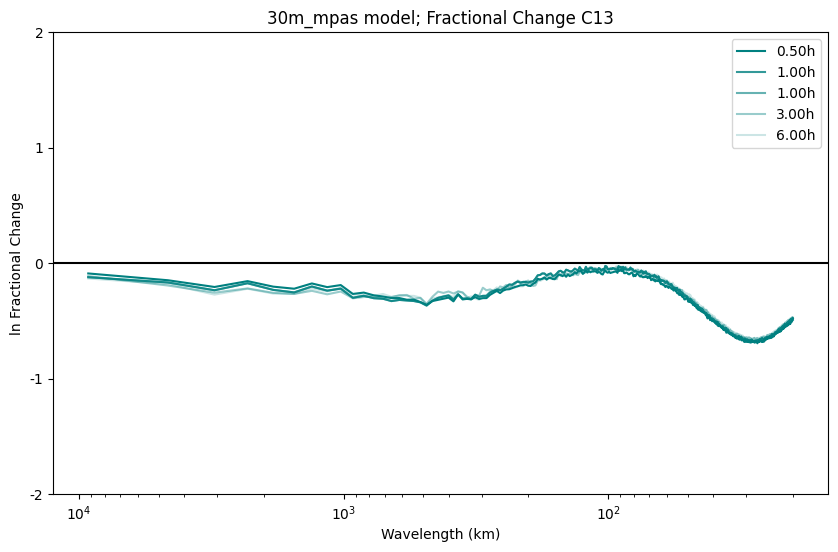

/glade/derecho/scratch/dkimpara/tmp/ipykernel_28122/1036120911.py:15: RuntimeWarning: divide by zero encountered in divide
  wavelengths = 1 / np.fft.rfftfreq(min_c * 2, d=dx)[:-1]


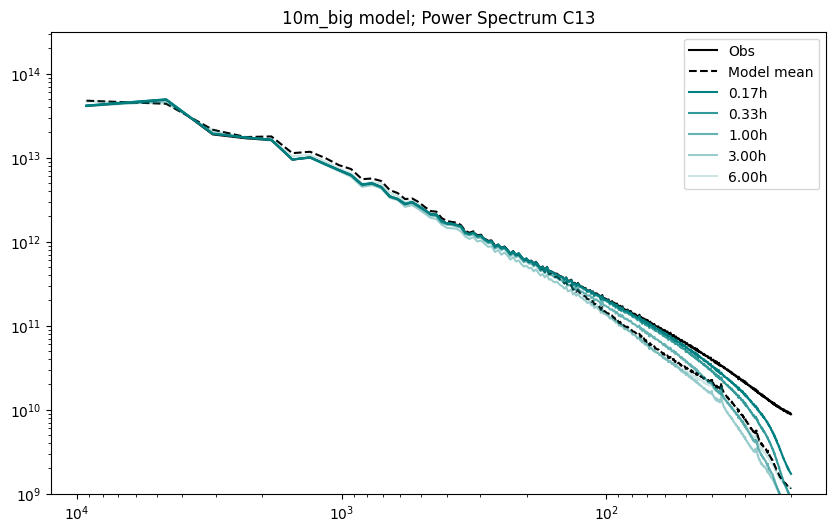

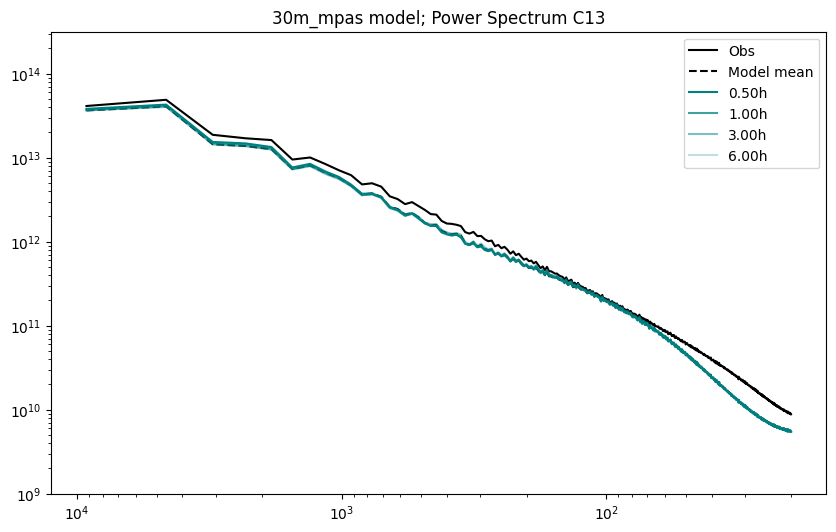

In [213]:
forecast_hours = [1, 3, 6]

models = ["10m_big", "30m_mpas"]

for model in models:
    plot_fft_fc_channel(model, 13, forecast_hours)

for model in models:
    plot_fft_channel(model, 13, forecast_hours, ylims=[1e9, 10 ** 14.5])

# FSS

In [9]:
def fss_plot(df, timestep, channel, fss_types, titles=None,
             percentile=False, tropics=False,suptitle=None):
    # With spacing control
    num_subplots = len(fss_types)
    fig, axes = plt.subplots(1, num_subplots, figsize=(5 * num_subplots, 4), sharey=True)
    fig.subplots_adjust(wspace=0.05)  # tighten horizontal gap

    axes[0].set_ylabel('Spatial scale (km)')

    for i, fss_type in enumerate(fss_types):
        ax = axes[i]
        # --- parse window sizes from column names ---
        def parse_window(col):
            m = re.search(f'WS(\d+)_C{channel:02}', col)
            return int(m.group(1)) if m else None

        fss_cols = [c for c in df.columns if c.startswith('FSS_WS') and c.endswith(f"C{channel:02}_{"PCT_" if percentile else ""}{fss_type}{"_tropics" if tropics else ""}")]
        windows  = np.array([parse_window(c) for c in fss_cols])
        # --- build matrix: rows=window sizes, cols=lead times ---
        lead_times = df.forecast_step * timestep / 60 # hours
        fss_matrix = df[fss_cols].values.T     # shape (n_windows, n_leads)

        windows_km = windows * 11
        y_values = windows_km
        # print(windows_km)
        # Map your values to [0, 1, 2, 3, ...] evenly
        def forward(y):
            return np.interp(y, y_values, np.arange(len(y_values)))

        def inverse(y):
            return np.interp(y, np.arange(len(y_values)), y_values)


        # mesh = ax.pcolormesh(x_edges, y_edges, fss_matrix, cmap='viridis_r', vmin=0, vmax=1, levels=levels)
        # cbar = plt.colorbar(mesh, ax=ax, label='FSS')
        # ax.set_ylim(y_edges[0], y_edges[-1])
        interval = 0.05
        levels = np.arange(0, 1 + interval, interval)
        cf = ax.contourf(lead_times, windows_km, fss_matrix,
                        levels=levels,
                        cmap='viridis')

        # get and plot skillful baseline
        skillful_threshold = 0.5 + df[f"obs_freq_C{channel:02}_{"PCT_" if percentile else ""}{fss_type}"].mean() / 2
        # print(skillful_threshold)
        contour_line = ax.contour(lead_times, windows_km, fss_matrix, levels=[skillful_threshold],  # use windows_km here
                colors='black', linewidths=1.5, linestyles='dotted')
        ax.clabel(contour_line, inline=True, inline_spacing=0, fontsize=10, fmt='%.2f', manual=False)
        # ax.pcolormesh(fss_matrix)
        # ax.set_yscale("log")

        ax.set_yscale(FuncScale(ax.yaxis, (forward, inverse)))
        # ax.set_yscale("log")
        # ax.set_yticks(y_values)
        ax.set_ylim(11, windows_km[-1] + 50) 


        ticks = [11, 25, 50, 75, 100, 150, 250, 500, 750, 1000, 1500, 2500]
        tick_labels = [10, 25, 50, 75, 100, 150, 250, 500, 750, 1000, 1500, 2500]
        ax.set_yticks(ticks)
        ax.set_yticklabels(tick_labels)

        ticks = list(range(1,13))
        ax.set_xticks(ticks)

        ax.set_xlabel('Lead time (hour)')

        ax.set_title(titles[i])
    fig.suptitle(suptitle)
    cbar = fig.colorbar(cf, ax=axes, location='right', pad=0.02, label="Fractional Skill Score")
    # fig.subplots_adjust(right=0.88)
    # cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    # fig.colorbar(cf, cax=cbar_ax, label="Fractional Skill Score")
    # plt.tight_layout()
    plt.show()

def get_fss_types(df, channel):
    return sorted(set(re.search(rf'C{channel:02}_(.+)$', c).group(1) for c in df.columns if "FSS" in c))


def fss_diff(df, timestep, channel, fss_types, titles=None,
             percentile=False, tropics=False,  region_right=False, suptitle=None,
             df_mpas=None, df_ml=None,
             diff_max=0.75):
    # With spacing control
    num_subplots = len(fss_types)
    fig, axes = plt.subplots(1, num_subplots, figsize=(5 * num_subplots, 4), sharey=True)
    fig.subplots_adjust(wspace=0.05)  # tighten horizontal gap
    axes[0].set_ylabel('Spatial scale (km)')

    for i, fss_type in enumerate(fss_types):
        ax = axes[i]
        # --- parse window sizes from column names ---
        def parse_window(col):
            m = re.search(f'WS(\d+)_C{channel:02}', col)
            return int(m.group(1)) if m else None

        fss_cols = [c for c in df.columns if c.startswith('FSS_WS') and c.endswith(f"C{channel:02}_{"PCT_" if percentile else ""}{fss_type}{"_tropics" if tropics else ""}{"_region_right" if region_right else ''}")]

        fss_cols = sorted(fss_cols, key=lambda x: int(re.search(r'_WS(\d+)_', x).group(1)))
        fss_df = df[fss_cols]
        fss_df = fss_df.reindex(fss_cols, axis=1)
        windows  = np.array([parse_window(c) for c in fss_cols])
        # --- build matrix: rows=window sizes, cols=lead times ---
        lead_times = np.arange(1, len(df) + 1) * timestep / 60 # hours

        fss_matrix = fss_df[fss_cols].values.T     # shape (n_windows, n_leads)
        windows_km = windows * 11
        y_values = windows_km
        # print(windows_km)
        # Map your values to [0, 1, 2, 3, ...] evenly
        def forward(y):
            return np.interp(y, y_values, np.arange(len(y_values)))

        def inverse(y):
            return np.interp(y, np.arange(len(y_values)), y_values)


        # mesh = ax.pcolormesh(x_edges, y_edges, fss_matrix, cmap='viridis_r', vmin=0, vmax=1, levels=levels)
        # cbar = plt.colorbar(mesh, ax=ax, label='FSS')
        # ax.set_ylim(y_edges[0], y_edges[-1])
        interval = 0.05
        levels = np.arange(-diff_max, diff_max+ interval, interval)
        cf = ax.contourf(lead_times, windows_km, fss_matrix,
                        levels=levels,
                        cmap='RdBu')


        ax.set_yscale(FuncScale(ax.yaxis, (forward, inverse)))
        ax.set_ylim(11, windows_km[-1] + 50) 
        
        contour_line = ax.contour(lead_times, windows_km, fss_matrix, levels=[0],  # use windows_km here
                colors='black', linewidths=1.5, linestyles='solid')
        # ax.clabel(contour_line, inline=True, inline_spacing=0, fontsize=10, fmt='%.2f', manual=False)

        for df_model in [df_mpas, df_ml]:
            if df_model is not None:
                fss_df = df_model[fss_cols]
                fss_df = fss_df.reindex(fss_cols, axis=1)
                fss_matrix = fss_df[fss_cols].values.T     # shape (n_windows, n_leads)
                skillful_threshold = 0.5 + df_model[f"obs_freq_C{channel:02}_{"PCT_" if percentile else ""}{fss_type}"].mean() / 2
                contour_line = ax.contour(lead_times, windows_km, fss_matrix, levels=[skillful_threshold],  # use windows_km here
                        colors='black', linewidths=1.5, linestyles='dotted')
        ax.clabel(contour_line, inline=True, inline_spacing=0, fontsize=10, fmt='%.2f (DOP+)', manual=False)

        ticks = [11, 25, 50, 75, 100, 150, 250, 500, 750, 1000, 1500, 2500]
        tick_labels = [10, 25, 50, 75, 100, 150, 250, 500, 750, 1000, 1500, 2500]
        ax.set_yticks(ticks)
        ax.set_yticklabels(tick_labels)

        ticks = list(range(1,13))
        ax.set_xticks(ticks)

        ax.set_xlabel('Lead time (hour)')

        ax.set_title(titles[i])
    fig.suptitle(suptitle)
    cbar = fig.colorbar(cf, ax=axes, location='right', pad=0.02, label="Fractions Skill Score Difference")
    # fig.subplots_adjust(right=0.88)
    # cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    # fig.colorbar(cf, cax=cbar_ax, label="Fractional Skill Score")
    # plt.tight_layout()

def get_fss_types(df, channel):
    return sorted(set(re.search(rf'C{channel:02}_(.+)$', c).group(1) for c in df.columns if "FSS" in c))




## FSS lines

FSS_WS1_C13_PCT235_region_right
FSS_WS40_C13_PCT235_region_right
FSS_WS200_C13_PCT235_region_right
FSS_WS1_C13_PCT255_region_right
FSS_WS40_C13_PCT255_region_right
FSS_WS200_C13_PCT255_region_right


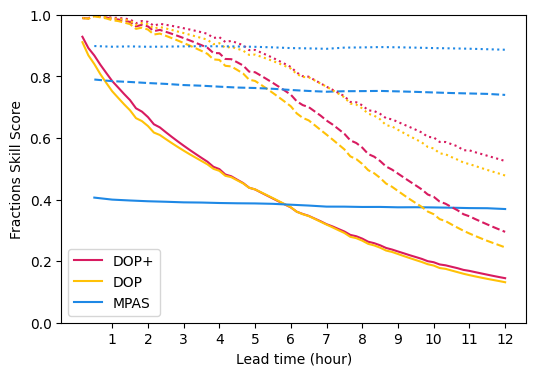

<Figure size 640x480 with 0 Axes>

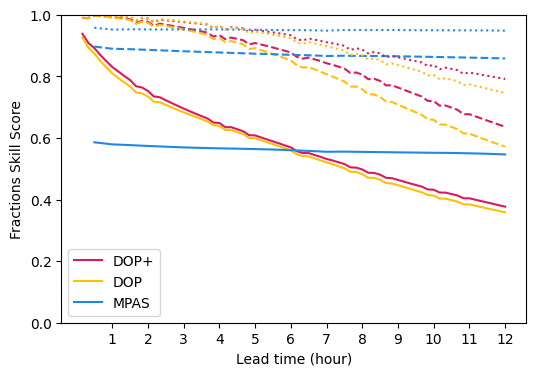

In [216]:

def fss_lines(models, channel, fss_type, fss_window_sizes, titles=None,
             percentile=False, tropics=False, region_right= False, suptitle=None,
             diff_max=0.75):
    fig, ax = plt.subplots(figsize=(6, 4))

    # With spacing control
    linestyles = ["-", "--", ":"]
    for i, fss_window_size in enumerate(fss_window_sizes):
        col_name = f"FSS_WS{fss_window_size}_C{channel:02}{'_PCT' if percentile else ''}{fss_type}{'_tropics' if tropics else ''}{'_region_right' if region_right else ''}"
        window_km = 11 * fss_window_size
        print(col_name)
        for model in models:
            fss_col = dfs[model][col_name]
            timestep = int(model[:2])
            lead_times = np.arange(1, len(fss_col) + 1) * timestep / 60 # hours
            plt.plot(lead_times, fss_col, color=colors[model], linestyle=linestyles[i],
                     label=model_labels[model] if i==0 else None)

            # print(fss_col.max() - fss_col.min())
        
    ticks = list(range(1,13))
    plt.xticks(ticks)

    plt.xlabel('Lead time (hour)')
    plt.ylabel('Fractions Skill Score')
    plt.ylim([0,1])
    plt.suptitle(suptitle)
    plt.legend()


# 10m_big_train_anneal
fss_lines(["10m_big", "10m_big_train_anneal", "30m_mpas"], 13, "235", [1, 40, 200], percentile=True, tropics=False, region_right=True)
plt.savefig("figures/T235.png", dpi=300)
plt.figure()
fss_lines(["10m_big", "10m_big_train_anneal", "30m_mpas"], 13, "255", [1, 40, 200], percentile=True, tropics=False, region_right=True)
plt.savefig("figures/T255.png", dpi=300)

# fss_lines(["30m_mpas", "10m_big"], 13, "255", [1, 40, 200], percentile=True, tropics=True)

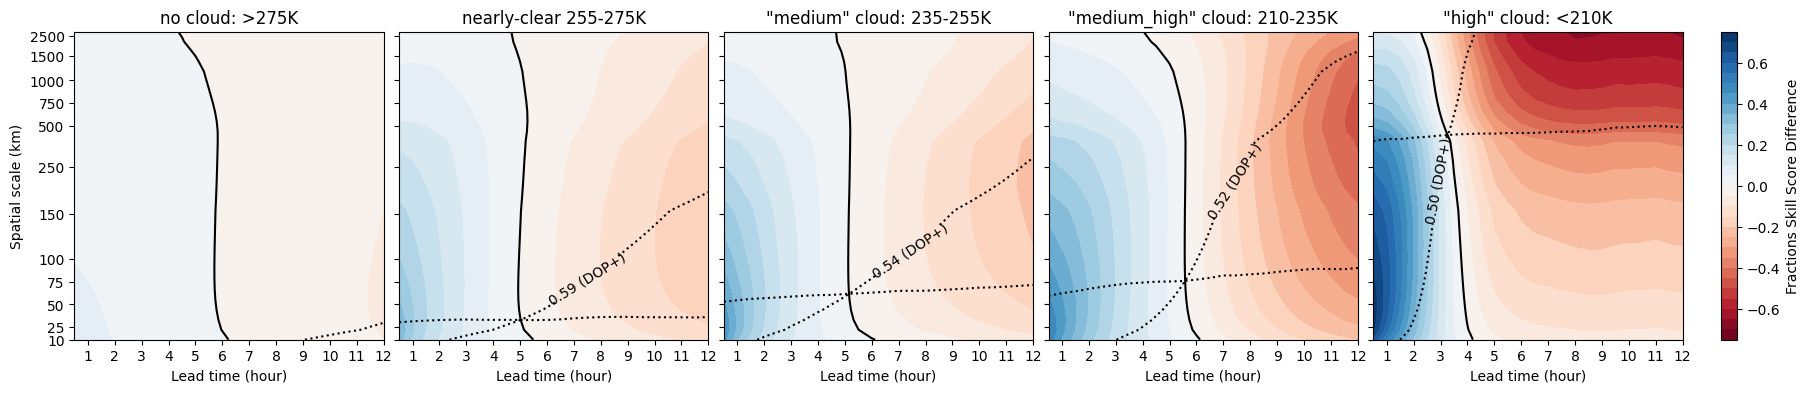

In [71]:
len_mpas = len(dfs["30m_mpas"])
df_10m = dfs["10m_big"].iloc[range(2, 3 * len_mpas + 1, 3)]

pct=True
fss_diff(df_10m.reset_index() - dfs["30m_mpas"], 30, 13, 
         ["none", "low", "medium", "medium_high", "high"], titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium_high" cloud: 210-235K''', '''"high" cloud: <210K'''],
        percentile=pct,
        suptitle="",
        df_ml=df_10m, df_mpas=dfs["30m_mpas"],
        )
plt.savefig("figures/fss_dop+_mpas.png")
# fss_diff(df_10m.reset_index() - dfs["30m_mpas"], 30, 13, 
#          ["none", "low", "medium", "medium_high", "high"], titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium_high" cloud: 210-235K''', '''"high" cloud: <210K'''],
#         percentile=pct,
#         tropics=True,
#         suptitle=f"DOP+ \N{MINUS SIGN} MPAS FSS percentile C13 ",
#         df_ml=df_10m, df_mpas=dfs["30m_mpas"],
#         )

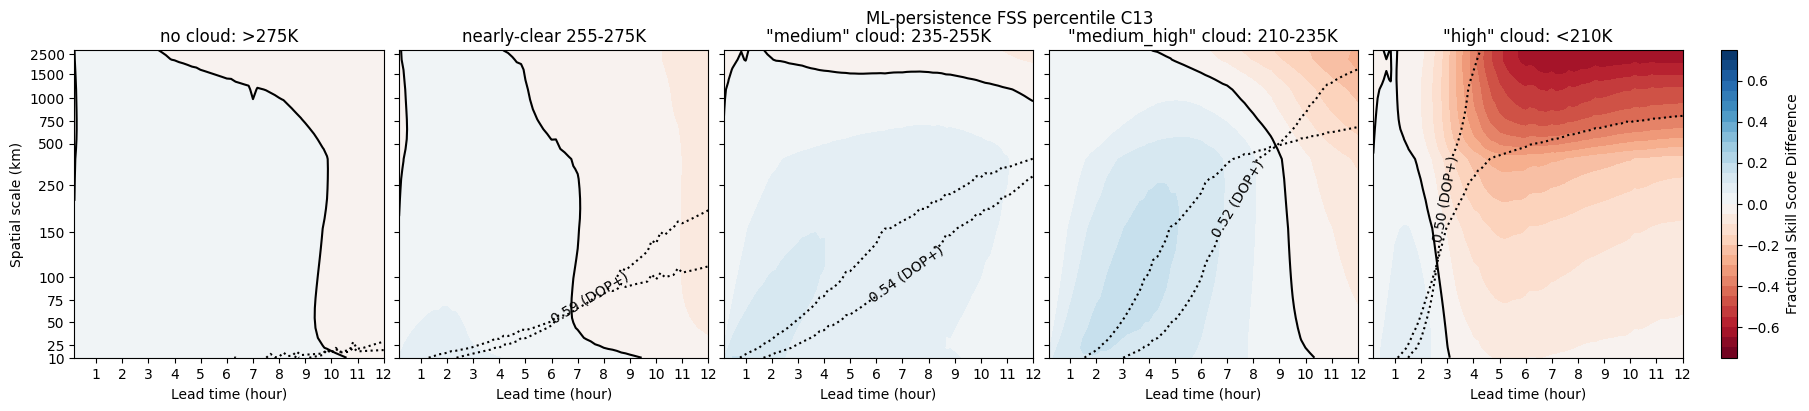

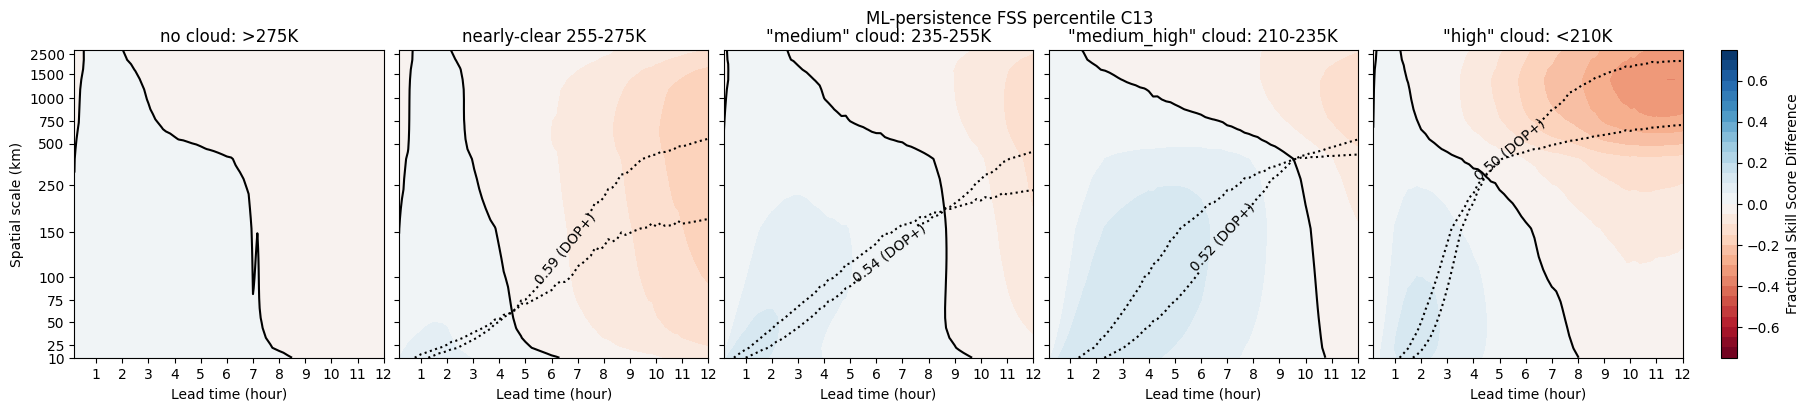

In [63]:
pct=True
fss_diff(dfs["10m_big"] - dfs["10m_persistence"], 10, 13, 
         ["none", "low", "medium", "medium_high", "high"], titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium_high" cloud: 210-235K''', '''"high" cloud: <210K'''],
        percentile=pct,
        suptitle=f"ML-persistence FSS percentile C13 ",
        df_ml=dfs["10m_big"], df_mpas= dfs["10m_persistence"],
)

fss_diff(dfs["10m_big"] - dfs["10m_persistence"], 10, 13, 
         ["none", "low", "medium", "medium_high", "high"], titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium_high" cloud: 210-235K''', '''"high" cloud: <210K'''],
        percentile=pct,
        tropics=True,
        suptitle=f"ML-persistence FSS percentile C13 ",
        df_ml=dfs["10m_big"], df_mpas= dfs["10m_persistence"],

        )

## DOP v DOP+

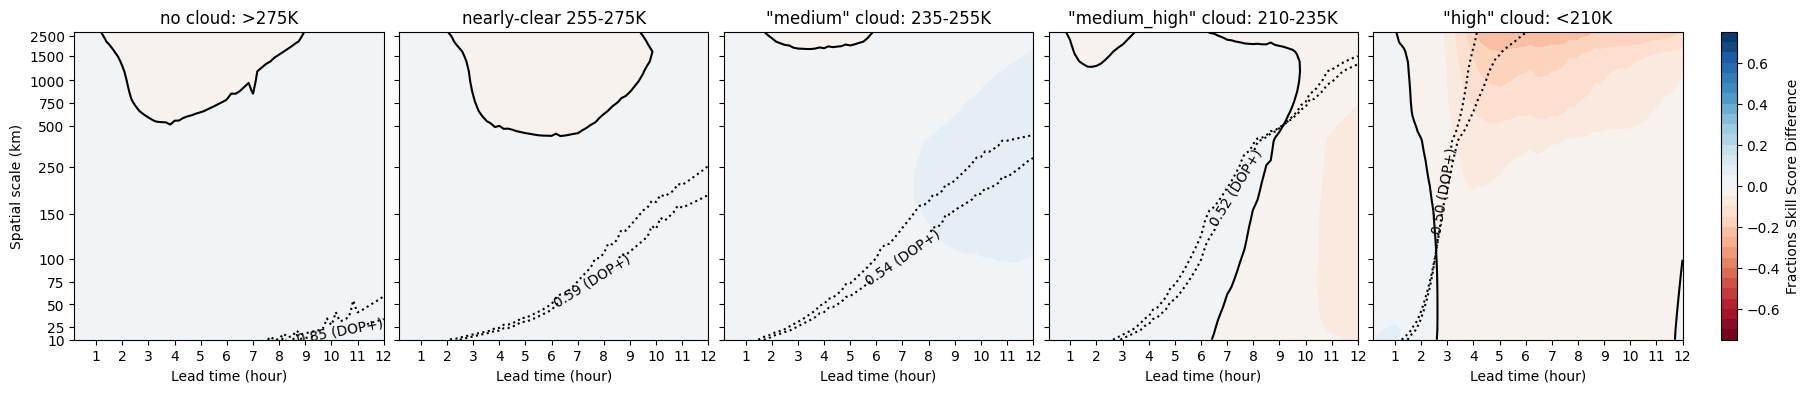

In [72]:
pct=True
fss_diff(dfs["10m_big"] - dfs["10m_big_dop"], 10, 13, 
         ["none", "low", "medium", "medium_high", "high"], titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium_high" cloud: 210-235K''', '''"high" cloud: <210K'''],
        percentile=pct, region_right=True,
        suptitle="",
        df_ml=dfs["10m_big"], df_mpas= dfs["10m_big_dop"],
)
plt.savefig("figures/fss_dop+_dop.png", dpi=300)
# fss_diff(dfs["10m_big"] - dfs["10m_big_dop"], 10, 13, 
#          ["none", "low", "medium", "medium_high", "high"], titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium_high" cloud: 210-235K''', '''"high" cloud: <210K'''],
#         percentile=pct,
#         tropics=True,
#         suptitle=f"DOP+ \N{MINUS SIGN} DOP FSS percentile C13 ",
#         df_ml=dfs["10m_big"], df_mpas= dfs["10m_big_dop"],
#         )

In [ ]:
len_mpas = len(dfs["30m_mpas"])
df_10m = dfs["10m_big"].iloc[range(2, 3 * len_mpas + 1, 3)]

pct=True
fss_diff(df_10m.reset_index() - dfs["30m_mpas"], 30, 13, 
         ["none", "low", "medium", "medium_high", "high"], titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium_high" cloud: 210-235K''', '''"high" cloud: <210K'''],
        percentile=pct,
        suptitle=f"ML-MPAS FSS percentile C13 "
        )
    

In [ ]:
for model in ["10m_big", "30m_mpas", "10m_persistence"]:
    pct=True
    fss_plot(dfs[model], int(model[:2]), 13, ["none", "low", "medium", "medium_high", "high"], titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium_high" cloud: 210-235K''', '''"high" cloud: <210K'''],
            percentile=pct,
            suptitle=f"{model} C13 percentile FSS")
    
    tropics=True
    fss_plot(dfs[model], int(model[:2]), 13, ["none", "low", "medium", "medium_high", "high"], titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium_high" cloud: 210-235K''', '''"high" cloud: <210K'''],
            percentile=pct, tropics=tropics,
            suptitle=f"{model} C13 percentile FSS tropics")
    

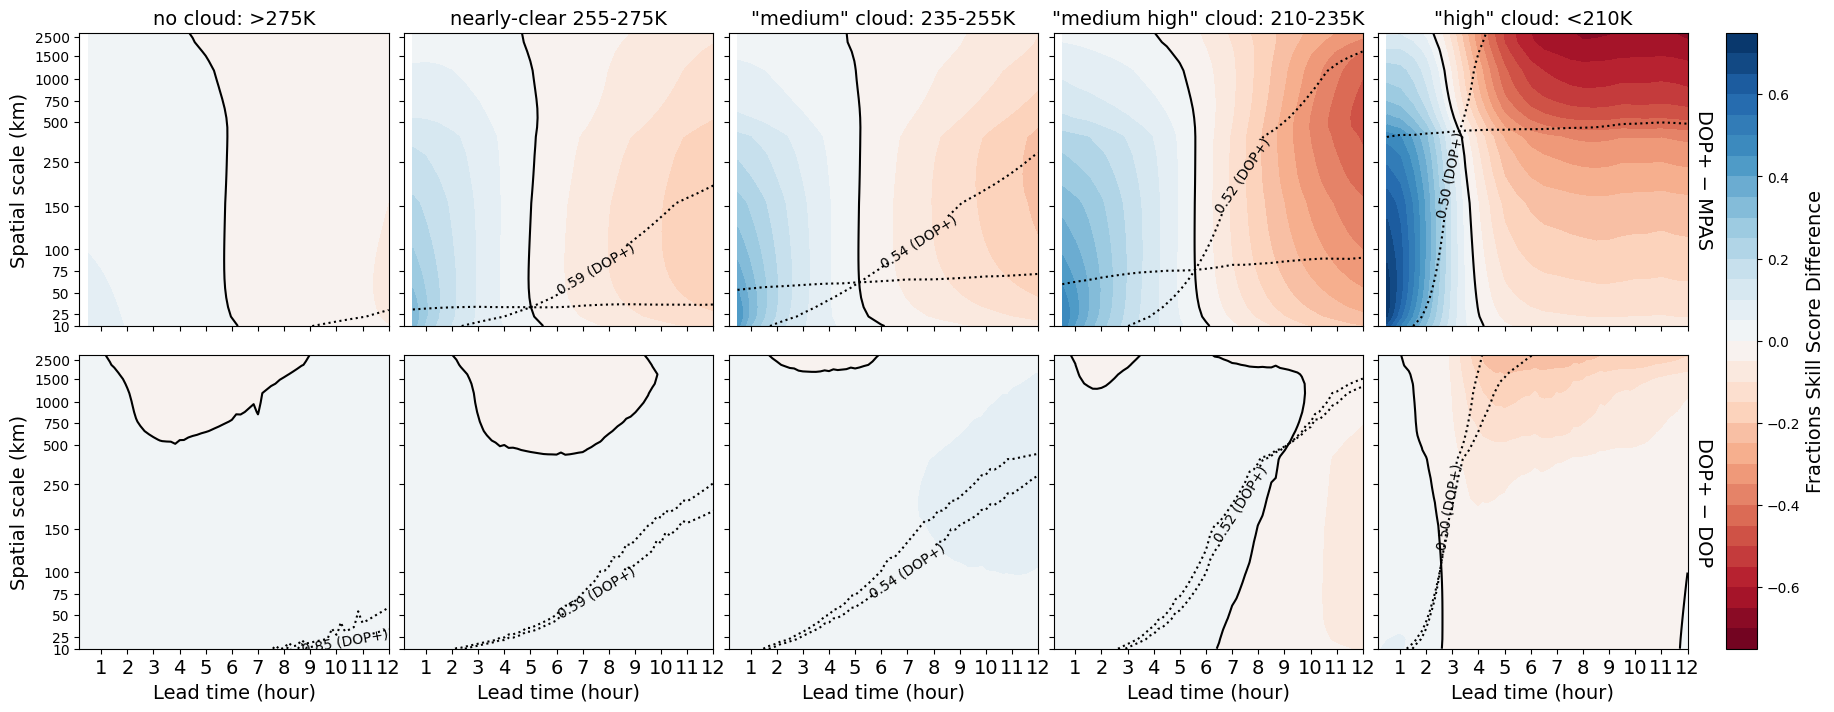

In [305]:
"""FSS-difference panels: one row, or several rows stacked with a shared x axis."""

import re

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.scale import FuncScale


Y_TICKS = [11, 25, 50, 75, 100, 150, 250, 500, 750, 1000, 1500, 2500]
Y_TICK_LABELS = [10, 25, 50, 75, 100, 150, 250, 500, 750, 1000, 1500, 2500]


def _col_tail(channel, fss_type, percentile, tropics, region_right):
    """Suffix that identifies the FSS columns for one panel."""
    return (f"C{channel:02}_"
            f"{'PCT_' if percentile else ''}"
            f"{fss_type}"
            f"{'_tropics' if tropics else ''}"
            f"{'_region_right' if region_right else ''}")


def plot_fss_diff_row(axes, df,channel, fss_types, timestep=None,
                      titles=None, percentile=False, tropics=False,
                      region_right=False, df_mpas=None, df_ml=None,
                      diff_max=0.75, interval=0.05,
                      show_xlabel=True, show_titles=True,
                      ylabel='Spatial scale (km)',row_label=None):
    """Draw one row of FSS-difference panels onto the given axes.

    Returns the last QuadContourSet, which is what you hand to fig.colorbar.
    """
    axes = np.atleast_1d(axes)
    if ylabel:
        axes[0].set_ylabel(ylabel)

    levels = np.arange(-diff_max, diff_max + interval, interval)
    cf = None

    for i, fss_type in enumerate(fss_types):
        ax = axes[i]

        # --- pick out and order the columns for this panel ---
        tail = _col_tail(channel, fss_type, percentile, tropics, region_right)
        fss_cols = [c for c in df.columns
                    if c.startswith('FSS_WS') and c.endswith(tail)]
        fss_cols = sorted(fss_cols,
                          key=lambda c: int(re.search(r'_WS(\d+)_', c).group(1)))

    
        
        windows = np.array([int(re.search(rf'WS(\d+)_C{channel:02}', c).group(1))
                            for c in fss_cols])
        windows_km = windows * 11

        

        fss_df = df[fss_cols]
        fss_df = fss_df.reindex(fss_cols, axis=1)
        
        lead_times = np.arange(1, len(df) + 1) * timestep / 60  # hours
        fss_matrix = df[fss_cols].values.T                      # (n_windows, n_leads)

        cf = ax.contourf(lead_times, windows_km, fss_matrix,
                         levels=levels, cmap='RdBu')

        # Even spacing of the (irregular) window sizes.
        # NOTE: bind windows_km as a default arg — FuncScale calls these at draw
        # time, so a bare closure would pick up the *last* loop iteration's array.
        def forward(y, v=windows_km):
            return np.interp(y, v, np.arange(len(v)))

        def inverse(y, v=windows_km):
            return np.interp(y, np.arange(len(v)), v)

        ax.set_yscale(FuncScale(ax.yaxis, (forward, inverse)))
        ax.set_ylim(11, windows_km[-1] + 50)

        # zero-difference contour
        ax.contour(lead_times, windows_km, fss_matrix, levels=[0],
                   colors='black', linewidths=1.5, linestyles='solid')

        # # skilful-scale contours for the reference models
        # for df_model in (df_mpas, df_ml):
        #     if df_model is not None:
        #         model_matrix = df_model[fss_cols].values.T
        #         obs_key = (f"obs_freq_C{channel:02}_"
        #                    f"{'PCT_' if percentile else ''}{fss_type}")
        #         skillful = 0.5 + df_model[obs_key].mean() / 2
        #         cl = ax.contour(lead_times, windows_km, model_matrix,
        #                         levels=[skillful], colors='black',
        #                         linewidths=1.5, linestyles='dotted')

        # ax.clabel(cl, inline=True, inline_spacing=0,
        #               fontsize=10, fmt='%.2f (DOP+)')
        iter=0
        for df_model in [df_mpas, df_ml]:
            if df_model is not None:
                fss_df = df_model[fss_cols]
                fss_df = fss_df.reindex(fss_cols, axis=1)
                fss_matrix = fss_df[fss_cols].values.T     # shape (n_windows, n_leads)
                skillful_threshold = 0.5 + df_model[f"obs_freq_C{channel:02}_{"PCT_" if percentile else ""}{fss_type}"].mean() / 2
                contour_line = ax.contour(lead_times, windows_km, fss_matrix, levels=[skillful_threshold],  # use windows_km here
                        colors='black', linewidths=1.5, linestyles='dotted')
                if iter == 1:
                    ax.clabel(contour_line, inline=True, inline_spacing=0, fontsize=10, fmt='%.2f (DOP+)', manual=False)

            iter+=1


        ax.set_yticks(Y_TICKS)
        ax.set_yticklabels(Y_TICK_LABELS)
        ax.set_xticks(list(range(1, 13)))

        if show_xlabel:
            ax.set_xlabel('Lead time (hour)')
        if show_titles and titles is not None:
            ax.set_title(titles[i])
    if row_label:
        if len(axes) > 1 or not ylabel:
            axes[-1].yaxis.set_label_position('right')
            axes[-1].set_ylabel(row_label, rotation=270, labelpad=18)
        else:
            # Single column: the right ylabel slot is the same axis as the left
            # one, so annotate instead of clobbering 'Spatial scale (km)'.
            axes[-1].annotate(row_label, xy=(1.02, 0.5),
                              xycoords='axes fraction', rotation=270,
                              va='center', ha='left')
    return cf


def fss_diff(df, timestep, channel, fss_types, titles=None,
             percentile=False, tropics=False, region_right=False,
             suptitle=None, df_mpas=None, df_ml=None, diff_max=0.75):
    """Single row — same signature and output as before."""
    n = len(fss_types)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4),
                             sharey=True, squeeze=False)
    axes = axes[0]
    fig.subplots_adjust(wspace=0.05)

    cf = plot_fss_diff_row(axes, df, channel, fss_types, timestep=timestep,
                           titles=titles, percentile=percentile,
                           tropics=tropics, region_right=region_right,
                           df_mpas=df_mpas, df_ml=df_ml, diff_max=diff_max)

    fig.suptitle(suptitle)
    fig.colorbar(cf, ax=axes, location='right', pad=0.02,
                 label="Fractions Skill Score Difference")
    return fig, axes


def fss_diff_stacked(rows, channel, fss_types, titles=None,
                     suptitle=None, diff_max=0.75,
                     panel_size=(5, 4), wspace=0.05, hspace=0.10,
                     shared_colorbar=None,
                     cbar_label="Fractions Skill Score Difference"):
    """Stack several fss_diff rows in one figure, sharing the x axis by column.

    rows : list of dicts, top row first. Each dict needs 'df'; it may also carry
           any of percentile, tropics, region_right, df_mpas, df_ml, diff_max
           to override the defaults.

    Example
    -------
    fss_diff_stacked(
        rows=[{'df': df_a},
              {'df': df_b, 'tropics': True}],
        timestep=60, channel=13, fss_types=['gt5', 'gt10', 'gt20'],
        titles=['> 5 mm', '> 10 mm', '> 20 mm'],
        suptitle='FSS difference vs. baseline')
    """
    n_rows, n_cols = len(rows), len(fss_types)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(panel_size[0] * n_cols, panel_size[1] * n_rows),
        sharex='col', sharey='row', squeeze=False)
    fig.subplots_adjust(wspace=wspace, hspace=hspace)

    row_maxes = [r.get('diff_max', diff_max) for r in rows]
    if shared_colorbar is None:
        shared_colorbar = len(set(row_maxes)) == 1

    cfs = []
    for j, row in enumerate(rows):
        opts = {k: v for k, v in row.items() if k != 'df'}
        opts.setdefault('diff_max', diff_max)
        cf = plot_fss_diff_row(
            axes[j], row['df'], channel, fss_types,
            titles=titles,
            show_titles=(j == 0),            # titles only on the top row
            show_xlabel=(j == n_rows - 1),   # x label only on the bottom row
            **opts)
        cfs.append(cf)

    if suptitle:
        fig.suptitle(suptitle)

    if shared_colorbar:
        fig.colorbar(cfs[-1], ax=axes, location='right',
                     pad=0.02, label=cbar_label)
    else:
        for j in range(n_rows):
            fig.colorbar(cfs[j], ax=axes[j], location='right',
                         pad=0.02, label=cbar_label)

    return fig, axes

len_mpas = len(dfs["30m_mpas"])
df_10m = dfs["10m_big"].iloc[range(2, 3 * len_mpas + 1, 3)]

with plt.rc_context({
    'font.size': 14,          # baseline; ticks and axis labels follow it
    'axes.titlesize': 14,     # panel titles
    'axes.labelsize': 14,     # "Lead time (hour)" / "Spatial scale (km)"
    'xtick.labelsize': 14,
    'ytick.labelsize': 10,
}): 
    fss_diff_stacked(
        rows=[{'df': df_10m.reset_index() - dfs["30m_mpas"], 'df_mpas':dfs["30m_mpas"], 'df_ml':df_10m,
               'timestep':30, 'percentile': True,
              'row_label':"DOP+ \N{MINUS SIGN} MPAS"},
              {'df': dfs["10m_big"] - dfs["10m_big_dop"],'df_mpas':dfs["10m_big_dop"], 'df_ml':dfs["10m_big"],
               'timestep':10, 'percentile': True, 'region_right': True,
             'row_label':"DOP+ \N{MINUS SIGN} DOP"}
             ],
        channel=13,
        fss_types=["none", "low", "medium", "medium_high", "high"], 
        titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium high" cloud: 210-235K''', '''"high" cloud: <210K'''],)
    plt.savefig("figures/fss_diff.png", dpi=300)

# FSS by init time

In [ ]:

for model in ["10m_big", "30m_mpas"]:
    for t in [0,6,12,18]:
        pct=True
        fss_plot(dfs_init_time[f"{model}_{t:02}z"], int(model[:2]), 13, ["none", "low", "medium", "medium_high", "high"], titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium_high" cloud: 210-235K''', '''"high" cloud: <210K'''],
                percentile=pct,
                suptitle=f"{model} C13 percentile FSS {t:02}z init")
        
        # tropics=True
        # fss_plot(dfs_init_time[f"{model}_{t:02}z"], int(model[:2]), 13, ["none", "low", "medium", "medium_high", "high"], titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium_high" cloud: 210-235K''', '''"high" cloud: <210K'''],
        #         percentile=pct, tropics=tropics,
        #         suptitle=f"{model} C13 percentile FSS tropics {t:02}z init")
        

## 12z - mean FSS

In [ ]:
pct=True

df_base = dfs["10m_big"]

df_init = dfs_init_time[f"10m_big_12z"].reindex(df_base.columns, axis=1)

fss_diff(df_init - df_base, 10, 13, 
         ["none", "low", "medium", "medium_high", "high"], titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium_high" cloud: 210-235K''', '''"high" cloud: <210K'''],
        percentile=pct,
        suptitle=f"",
        diff_max=0.2,
        )
    

# channel 9

In [ ]:
for model in ["10m_big", "30m_mpas"]:
    pct = True
    fss_types = ["dry", "moist", "clouds_1", "clouds_2", "clouds_3"]
    fss_plot(dfs[model], int(model[:2]), 9, fss_types,
                titles=fss_types,
            percentile=pct, tropics=tropics,
            suptitle=f"{model} C09 percentile FSS")

    tropics = True
    fss_plot(dfs[model], int(model[:2]), 9, fss_types, 
            titles=fss_types,
            percentile=pct, tropics=tropics,
            suptitle=f"{model} C09 percentile FSS tropics")


In [ ]:
# bins
import yaml
config = "/glade/u/home/dkimpara/miles-credit/config_goes/example_eval.yml"

with open(config) as cf:
    conf = yaml.load(cf, Loader=yaml.FullLoader)

all_df = dfs_all["30m_mpas"]
channel = 13
tropics = True
fss_conf = conf["FSS"][channel]
categories = fss_conf["sky_categories"]

for category, bin_edges in categories.items():
    col_name = f"bin_edges_C{channel:02}_PCT_{category}{"_tropics" if tropics else ""}"
    all_edges = [df[col_name] for df in all_df]
    low_edge = pd.concat(all_edges, ignore_index=True, axis=0).apply(lambda x: x[0])
    high_edge = pd.concat(all_edges, ignore_index=True, axis=0).apply(lambda x: x[1])

    plt.hist(low_edge, bins=20)
    plt.hist(high_edge, bins=20)
    if bin_edges[0] != 0:
        plt.axvline(np.clip(bin_edges[0], 150, 320))
    if bin_edges[1] != 1000:
        plt.axvline(np.clip(bin_edges[1], 150, 320))

In [ ]:
# plot bias 10m_big out to 3h

timestep = 1/6
for i in [1,2,3]:
    forecast_step = int(i / timestep)
    steps = range(forecast_step - 2, forecast_step + 3)
    bias_files = [f"/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts/bias_step{step:02}.nc" for step in steps]
    datasets = [xr.open_dataarray(f) for f in bias_files]

    mean_bias = sum(datasets) / len(datasets)

    mean_bias.sel(channel=13).plot()
    plt.title(f"mean bias at {i:02}h")
    plt.show()


In [ ]:
# plot bias mpas out to 3h

steps_per_hour = 2
for i in [1,2,3]:
    forecast_step = i * steps_per_hour
    steps = range(forecast_step - 1, forecast_step + 1)
    bias_files = [f"/glade/derecho/scratch/dkimpara/goes_10km_train/mpas/mpas_fixed/bias_step{step:02}.nc" for step in steps]
    datasets = [xr.open_dataarray(f) for f in bias_files]

    mean_bias = sum(datasets) / len(datasets)

    mean_bias.sel(channel=13).plot()
    plt.title(f"mean bias at {i:02}h")
    plt.show()


# confusion matrix

In [249]:
def get_confusion_matrix(model, fh, order, labels,
                   channel=13, tropics=False,
                   region_right=False,):
    df = dfs[model]
    timestep = int(model[:2]) / 60.
    fs = int(fh/timestep)
    df = df[df["forecast_step"] == fs]
    
    confusion_cols = [c for c in df.columns if "confusion" in c and f"C{channel:02}" in c]
    if tropics:
        confusion_cols = [c for c in confusion_cols if "tropics" in c]
    elif region_right:
        confusion_cols = [c for c in confusion_cols if "region_right" in c]
    else:
        confusion_cols = [c for c in confusion_cols if "tropics" not in c and "region_right" not in c]
    
    array = df[confusion_cols].to_numpy()
    confusion_matrix = np.stack([c for c in array[0]], axis=0)

    return confusion_matrix
    
def plot_confusion(model, fh, order, labels,
                   channel=13, tropics=False,
                   region_right=False,
                  title=None):
    confusion_matrix = get_confusion_matrix(model,fh,order,labels,channel,tropics,region_right)
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix,
                                  display_labels=labels)
    disp.plot(cmap="Blues", im_kw=dict(vmin=0, vmax=0.9))
    disp.ax_.set_yticks(np.arange(len(labels)), labels, rotation=90, va="center")
    disp.ax_.tick_params(axis='both', labelsize=8)
    plt.xlabel("Predicted category")
    plt.ylabel("Observed category")
    plt.title(title)

def plot_confusions(models, fh, order, labels,
                    channel=13, tropics=False,
                    region_right=False,
 figsize=None):
    n = len(models)
    if figsize is None:
        figsize = (4 * n, 4)
    fig, axes = plt.subplots(1, n, figsize=figsize, squeeze=False, layout="constrained", gridspec_kw={'wspace': 0.05})
    axes = axes[0]
    fig.get_layout_engine().set(w_pad=0.02, wspace=0.02)
    for i, (model, ax) in enumerate(zip(models, axes)):
        cm = get_confusion_matrix(model, fh, order, labels,
                                  channel, tropics, region_right)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=labels)
        disp.plot(cmap="Blues", im_kw=dict(vmin=0, vmax=0.9),
                  text_kw=dict(fontsize=14),
                  values_format=".3f",
                  ax=ax, colorbar=False)

        if i==0:
            ax.set_yticks(np.arange(len(labels)), labels, rotation=90, va="center")
        else:
            # disp.ax_.set_yticks(np.arange(len(labels)), len(labels) * [""], rotation=90, va="center")
            disp.ax_.tick_params(labelleft=False)

        ax.tick_params(axis='both', labelsize=8.5)
        ax.set_xlabel("Predicted category")
        ax.set_ylabel("Observed category" if i == 0 else "")
        ax.set_title(model_labels.get(model, None))

    fig.colorbar(disp.im_, ax=axes, fraction=0.025, pad=0.02, shrink=0.84)
    return fig, axes

def plot_confusion_diff(model1, model2, fh, order, labels,
                   channel=13, tropics=False,
                   region_right=False,
                  title=None):

    confu1 = get_confusion_matrix(model1,fh,order,labels,channel,tropics,region_right)
    confu2 = get_confusion_matrix(model2,fh,order,labels,channel,tropics,region_right)
    diff = confu1 - confu2
    
    disp = ConfusionMatrixDisplay(confusion_matrix=diff,
                                  display_labels=labels)

    blues = plt.cm.Blues(np.linspace(0, 0.9, 128))  # dark→light
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "blue_white_blue",
        np.vstack([blues[::-1], blues])  # dark-blue → white → dark-blue
    )
    disp.plot(cmap=cmap, im_kw=dict(vmin=-0.2, vmax=0.2),
             text_kw=dict(fontsize=10),)
    
    disp.ax_.set_yticks(np.arange(len(labels)), labels, rotation=90, va="center")
    disp.ax_.tick_params(axis='both', labelsize=8)
    plt.xlabel("Predicted category")
    plt.ylabel("Observed category")
    plt.title(title)

In [250]:
order = ["high", "medium_high", "medium", "low", "none"]
cat_labels = list(reversed(["no cloud",
          '''nearly-clear''',
          '''"medium"''', 
          '''"medium high"''',
          '''"high"''']))
fh = 1

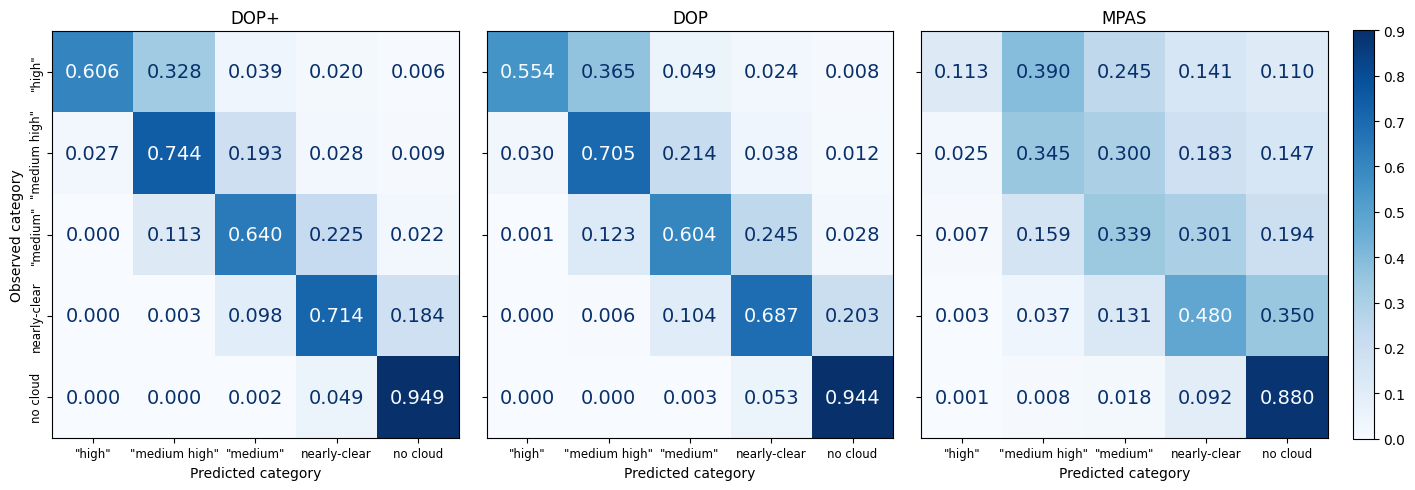

In [251]:
models = ["10m_big", "10m_big_dop", "30m_mpas"]
plot_confusions(models, fh, order, cat_labels, tropics=False, region_right=True, figsize=[14,5])
plt.savefig("figures/confusion_models.png", dpi=300)

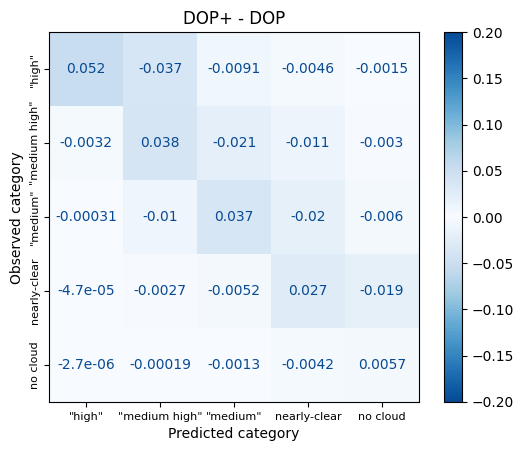

In [252]:
plot_confusion_diff("10m_big", "10m_big_dop", fh, order, cat_labels, tropics=False, region_right=True, title="DOP+ - DOP")
plt.savefig("figures/confusion_dop+_dop.png", dpi=300)

# histogram

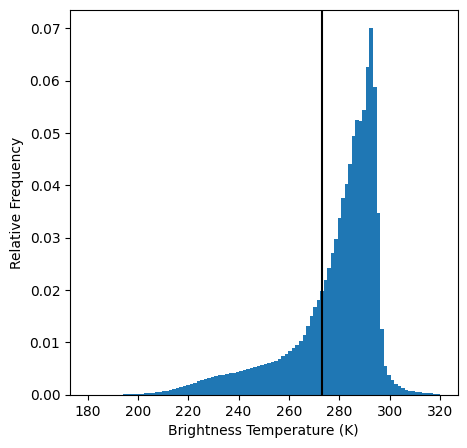

In [253]:
hist_file = "/glade/derecho/scratch/dkimpara/goes_10km_train/baselines/hist.npy"
edges_file = "/glade/derecho/scratch/dkimpara/goes_10km_train/baselines/hist_edges.npy"

hist = np.load(hist_file)
edges = np.load(edges_file)

plt.figure(figsize=(5, 5))
plt.stairs(hist / np.sum(hist), edges, fill=True)
plt.xlabel('Brightness Temperature (K)')
plt.ylabel('Relative Frequency')
plt.axvline(273, c="0")
# plt.title('Histogram of Band 13')
plt.savefig('histogram.png', dpi=300)